In [ ]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm
from scipy.spatial import distance
import matplotlib as mpl
import os
import glob
import re
import anndata as ad

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [ ]:
#tumor_states = pd.read_csv("../files/GBM_states.csv", index_col = 0)["newlabel_v3_level2"].to_dict()
path2ref = "../data/copy_number_results/clone_IDs.csv"
tumor_states = pd.read_csv('../../../data/GBM_LEAP_annotations/cell_metadata_all.csv')

/tmp/ipykernel_981703/315810261.py:3: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  tumor_states = pd.read_csv('/nfs/team283/GBM_LEAP/GBM_LEAP_annotations/cell_metadata_all.csv')


In [ ]:
all_ref = pd.read_csv(path2ref, index_col = 0)
all_ref = all_ref.rename(columns={'cell_class':'cell_type_coarse'})

In [ ]:
malignant_ct = list(set((tumor_states[tumor_states['cell_status']=='Malignant']
    ['annotation_granular'].tolist())))

In [ ]:
all_ref = all_ref[all_ref.cell_type2.isin(malignant_ct)]

In [ ]:
all_ref

,index,section,cell_type1,cell_type2,cell_type_coarse,predicted,predicted_probability
0,cellranger-arc201_count_f1cc177d08dc1bdbcdb402...,AT6-BRA-3-FO-2,Hypoxic,Hypoxic 1,AC-gliosis-hypoxia,0,1.000000
1,cellranger-arc201_count_f1cc177d08dc1bdbcdb402...,AT6-BRA-3-FO-2,AC-progenitor-like,AC progenitor-like 3,AC-gliosis-hypoxia,4,0.999999
2,cellranger-arc201_count_f1cc177d08dc1bdbcdb402...,AT6-BRA-3-FO-2,OPC-like,OPC-like 1,OPC-NPC-like,1,0.999951
3,cellranger-arc201_count_f1cc177d08dc1bdbcdb402...,AT6-BRA-3-FO-2,AC-progenitor-like,AC progenitor-like 3,AC-gliosis-hypoxia,4,0.991860
4,cellranger-arc201_count_f1cc177d08dc1bdbcdb402...,AT6-BRA-3-FO-2,AC-progenitor-like,AC progenitor-like 1,AC-gliosis-hypoxia,2,0.999998
...,...,...,...,...,...,...,...
429383,cellranger-arc201_count_fb5164779957be119e1205...,AT14-BRA-4-FO-2,OPC-like,OPC-like 1,OPC-NPC-like,diploid,0.654259
429385,cellranger-arc201_count_fb5164779957be119e1205...,AT14-BRA-4-FO-2,OPC-like,OPC-like 1,OPC-NPC-like,diploid,1.000000
429387,cellranger-arc201_count_fb5164779957be119e1205...,AT14-BRA-4-FO-2,AC-gliosis-like,AC-gliosis-like 3,AC-gliosis-hypoxia,diploid,1.000000
429388,cellranger-arc201_count_fb5164779957be119e1205...,AT14-BRA-4-FO-2,AC-gliosis-like,AC-gliosis-like 3,AC-gliosis-hypoxia,diploid,1.000000


In [ ]:
all_ref["patient"] = all_ref.section.str.split("-").str[0]
all_ref["clone"] = [f"{x}_{y}" for x,y in zip(all_ref.patient, all_ref.predicted)]
all_ref.dropna(subset = "cell_type_coarse", inplace = True)
all_ref = all_ref[all_ref.predicted != "diploid"]
all_ref = all_ref[all_ref.predicted_probability>0.9]
all_ref = all_ref.sort_values(by = "predicted")

In [ ]:
def plot_stacked_bar(dataframe, column1, column2, palette=None, pivot = False, save = None):
    """
    Plots a normalized stacked bar chart based on two columns of a pandas DataFrame.

    Parameters:
    - dataframe: pandas.DataFrame containing the data.
    - column1: string, the name of the column to group data by.
    - column2: string, the name of the column to use for stacking values.
    - palette: list or dict, colors to use for each category in column2.

    Outputs:
    - A normalized stacked bar plot with the legend outside the plot area.
    """
    # Pivot the data to get sums for each category in column2 for each unique value in column1
    if not pivot:
        pivot_table = dataframe.groupby([column1, column2]).size().unstack().fillna(0)
        
        # Normalize the data by row to make the sum of each row equal to 1
        pivot_table_normalized = pivot_table.div(pivot_table.sum(axis=1), axis=0)
        pivot_table_normalized["pat_id"] = [int(x.split("_")[0][2:]) for x in pivot_table_normalized.index]
        pivot_table_normalized["clone_id"] = [int(x.split("_")[1]) for x in pivot_table_normalized.index]
        pivot_table_normalized = pivot_table_normalized.sort_values(by = ["pat_id","clone_id"])
        pivot_table_normalized.drop(columns = ["pat_id","clone_id"], inplace = True)
        
    else:
        pivot_table_normalized = dataframe
    
    # Plotting the stacked bar chart
    ax = pivot_table_normalized.plot(kind='bar', stacked=True, color=palette, figsize=(12, 4))
    plt.xlabel("Clone")
    plt.ylabel('Proportion')
    plt.legend(title="Cell state", bbox_to_anchor=(1.05, 1), loc='upper left')

    # Removing top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Adding vertical lines to separate different patients
    # Extract patient IDs from clone labels
    patients = [label.split('_')[0] for label in pivot_table_normalized.index]
    # Find where patients change in the list
    changes = [i for i in range(1, len(patients)) if patients[i] != patients[i-1]]
    # Draw vertical lines at these change points
    for change in changes:
        plt.axvline(x=change - 0.5, color='grey', linestyle='--', linewidth=2)
    if save != None:
        plt.tight_layout()
        plt.savefig(save, bbox_inches='tight', dpi = 300)
    plt.show()
    return(pivot_table_normalized)

In [ ]:
palette = {
    'AC-gliosis-hypoxia': (163/255, 92/255, 31/255),
    'Neuron-like': (192/255, 189/255, 190/255),
    'OPC-NPC-like': (212/255, 216/255, 122/255),
    'Proliferative': (53/255, 174/255, 227/255)
}
color_palette = {
    # Brownish shades for Gliosis-like, AC-gliosis-like, Hypoxic, and AC-progenitor-like
    "Gliosis-like": "#cd853f",
    "AC-gliosis-like": "#a0522d",
    "Hypoxic": "#bc8f8f",
    "AC-progenitor-like": "#8b4513",
    
    # Specific greyish shade for all NPC-neuronal-like
    "NPC-neuronal-like": "#c0bdbd",
    
    # Yellow-green shades for OPC-like, OPC-NPC-like, and OPC-neuronal-like
    "OPC-like": "#c0d860",
    "OPC-NPC-like": "#9ec85e",
    "OPC-neuronal-like": "#acd748",
    
    # Specific blue shade for all Proliferative types
    "Proliferative": "#35aee3"
}

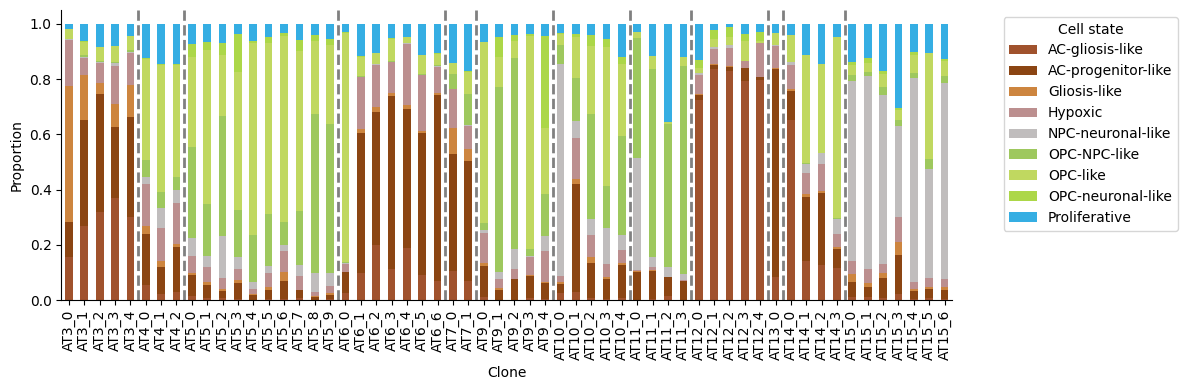

In [ ]:
pivot_ref= plot_stacked_bar(all_ref, "clone", "cell_type1", color_palette, save = "manuscript_figures/clone2state_fine.pdf")

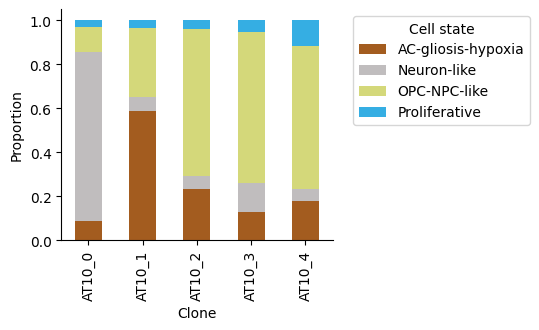

In [ ]:
def plot_stacked_bar(dataframe, column1, column2, palette=None, pivot = False, save = None):
    """
    Plots a normalized stacked bar chart based on two columns of a pandas DataFrame.

    Parameters:
    - dataframe: pandas.DataFrame containing the data.
    - column1: string, the name of the column to group data by.
    - column2: string, the name of the column to use for stacking values.
    - palette: list or dict, colors to use for each category in column2.

    Outputs:
    - A normalized stacked bar plot with the legend outside the plot area.
    """
    # Pivot the data to get sums for each category in column2 for each unique value in column1
    if not pivot:
        pivot_table = dataframe.groupby([column1, column2]).size().unstack().fillna(0)
        
        # Normalize the data by row to make the sum of each row equal to 1
        pivot_table_normalized = pivot_table.div(pivot_table.sum(axis=1), axis=0)
        pivot_table_normalized["pat_id"] = [int(x.split("_")[0][2:]) for x in pivot_table_normalized.index]
        pivot_table_normalized["clone_id"] = [int(x.split("_")[1]) for x in pivot_table_normalized.index]
        pivot_table_normalized = pivot_table_normalized.sort_values(by = ["pat_id","clone_id"])
        pivot_table_normalized.drop(columns = ["pat_id","clone_id"], inplace = True)
        
    else:
        pivot_table_normalized = dataframe
    
    # Plotting the stacked bar chart
    ax = pivot_table_normalized.plot(kind='bar', stacked=True, color=palette, figsize=(3.5, 3))
    plt.xlabel("Clone")
    plt.ylabel('Proportion')
    plt.legend(title="Cell state", bbox_to_anchor=(1.05, 1), loc='upper left')

    # Removing top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Adding vertical lines to separate different patients
    # Extract patient IDs from clone labels
    patients = [label.split('_')[0] for label in pivot_table_normalized.index]
    # Find where patients change in the list
    changes = [i for i in range(1, len(patients)) if patients[i] != patients[i-1]]
    # Draw vertical lines at these change points
    for change in changes:
        plt.axvline(x=change - 0.5, color='grey', linestyle='--', linewidth=2)
    if save != None:
        plt.tight_layout()
        plt.savefig(save, bbox_inches='tight', dpi = 300)
    plt.show()
    return(pivot_table_normalized)

pivot_ref= plot_stacked_bar(
    all_ref[all_ref.patient.isin(["AT10"])], "clone", "cell_type_coarse", 
    palette, save = None)

In [ ]:
pivot_ref.to_csv('../../../data/Fig4/Fig4b_AT10_clone_composition.csv')

In [ ]:
site_comp = all_ref[all_ref.patient.isin(['AT10'])][['section', 'predicted']].value_counts().reset_index()\
    .pivot(index = 'section', columns = 'predicted', values = 'count').dropna(axis=1, how = 'all')

<Axes: xlabel='section'>

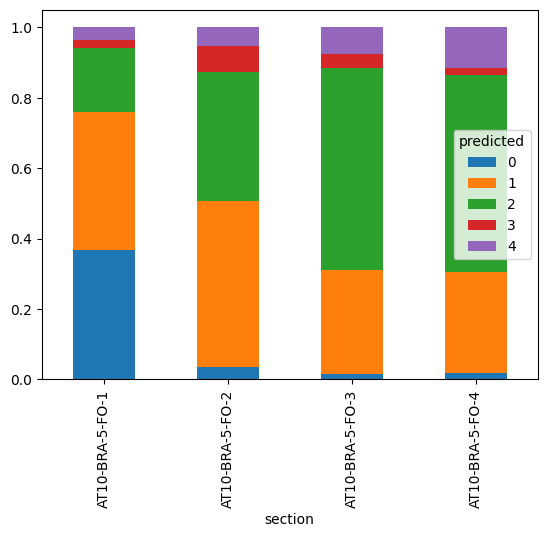

In [ ]:
site_comp.divide(site_comp.sum(axis=1), axis=0).plot.bar(stacked=True)

In [ ]:
site_comp.to_csv('../../../data/Fig4/Fig4b2.csv')